<a href="https://colab.research.google.com/github/sharmaaviraj/Deep-Learning-Assignment-Reports/blob/main/Deep_Learning_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("fashion_mnist")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("fashion_mnist"):
    print(root)
    print(files)

fashion_mnist
['train-labels-idx1-ubyte', 'train-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv']


In [ ]:
import pandas as pd

train_data = pd.read_csv("fashion_mnist/fashion-mnist_train.csv")
test_data = pd.read_csv("fashion_mnist/fashion-mnist_test.csv")

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (60000, 785)
Testing data shape: (10000, 785)


In [ ]:
X_train = train_data.drop("label", axis=1)
y_train = train_data["label"]

X_test = test_data.drop("label", axis=1)
y_test = test_data["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

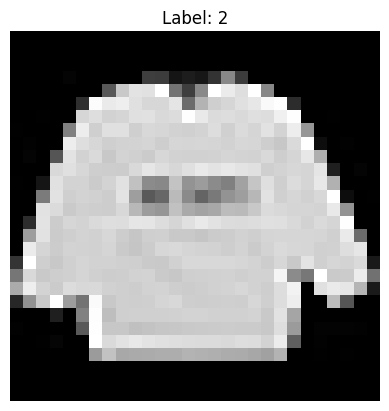

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X_train.iloc[0].values.reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train.iloc[0]}")
plt.axis("off")
plt.show()

In [ ]:
train_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

In [ ]:
import numpy as np

X = X.to_numpy()
X = X.reshape(X.shape[0], 28 * 28)

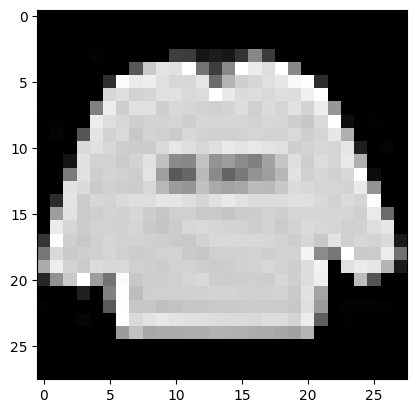

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(48000, 784)
(12000, 784)
(48000,)
(12000,)


In [ ]:
print(X.min())
print(X.max())

0
255


In [ ]:
X = X.astype('float32') / 255.0

In [ ]:
print(X.min())
print(X.max())

0.0
0.003921569


In [ ]:
import torch
from torch import nn

class Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, features):
        out = self.network(features)
        return out

In [ ]:
lr = 0.01
epochs = 20

m = Model(X_train.shape[1])

optimizer = torch.optim.Adam(m.parameters(), lr=lr)

loss_fn = nn.CrossEntropyLoss()

In [ ]:
print(y_train.dtype)
print(y_test.dtype)

torch.int64
int64


In [ ]:
loss = nn.CrossEntropyLoss()

for i in range(epochs):
    y_pred = m(X_train)
    l = loss(y_pred, y_train)

    optimizer.zero_grad()
    l.backward()
    optimizer.step()

    print(f"{l.item():.4f} loss at epoch {i}")

1.9492 loss at epoch 0
1.9397 loss at epoch 1
1.9382 loss at epoch 2
1.9379 loss at epoch 3
1.9331 loss at epoch 4
1.9287 loss at epoch 5
1.9251 loss at epoch 6
1.9204 loss at epoch 7
1.9153 loss at epoch 8
1.9107 loss at epoch 9
1.9069 loss at epoch 10
1.9052 loss at epoch 11
1.9046 loss at epoch 12
1.9019 loss at epoch 13
1.8996 loss at epoch 14
1.8957 loss at epoch 15
1.8907 loss at epoch 16
1.8867 loss at epoch 17
1.8833 loss at epoch 18
1.8801 loss at epoch 19


In [ ]:
with torch.no_grad():
    for i in range(X_test,shape[0]):
       y_pred = m(X_test)


AttributeError: 'Series' object has no attribute 'float'